# Customer Churn Prediction Pipeline
XGBoost vs Logistic Regression, both tuned to the same 92% recall. Dataset: Kaggle Telco Customer Churn.

**Leakage control:** every step that learns from data (imputation, outlier clipping, scaling, encoding, SMOTE/class weights) sits inside a scikit-learn Pipeline and is fitted on training data only.

In [1]:
# !pip install kagglehub xgboost imbalanced-learn
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score, f1_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve,
                             PrecisionRecallDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET_RECALL = 0.92
USE_SMOTE = False   # False = class weights, True = SMOTE (only applied if data is imbalanced)

## [1] Data Ingestion

In [2]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(df.shape)
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## [2] Data Cleaning (row-level only, nothing is learned from the data)

In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Fix data types
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

# Missing values are only inspected here; they are imputed later inside the Pipeline (train-fitted)
print(df.isna().sum()[df.isna().sum() > 0])

TotalCharges    11
dtype: int64


## [3] Feature Engineering (row-wise formulas, no fitted statistics)

In [4]:
df["charge_trend"] = df["MonthlyCharges"] - df["TotalCharges"] / df["tenure"].clip(lower=1)
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72, np.inf],
                            labels=["0-12", "13-24", "25-48", "49-72", "72+"]).astype(str)
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)

## [4] Target Definition

In [5]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})   # 1 = churned, 0 = retained
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## [5] Train / Test Split (stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

Train churn rate: 0.265 | Test churn rate: 0.265


## [6] Preprocessing Pipeline (fitted on training data only)
Missing-value imputation, outlier clipping (1st-99th percentile), scaling and one-hot encoding all live inside the ColumnTransformer. Percentiles, medians and modes are computed from the training rows only (and from each training fold during cross-validation).

In [7]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    # Learns the 1st / 99th percentile bounds in fit() and applies them in transform()
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.low_ = np.nanquantile(X, self.lower, axis=0)
        self.high_ = np.nanquantile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.low_, self.high_)

continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges", "charge_trend"]
other_num_cols = [c for c in X_train.select_dtypes(include=np.number).columns if c not in continuous_cols]
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("continuous", Pipeline([("impute", SimpleImputer(strategy="median")),
                             ("clip", QuantileClipper()),
                             ("scale", StandardScaler())]), continuous_cols),
    ("other_num", Pipeline([("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler())]), other_num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

## [7] Class Imbalance Handling (only if imbalanced)

In [8]:
minority_share = y_train.mean()
is_imbalanced = minority_share < 0.40 or minority_share > 0.60
print(f"Minority share: {minority_share:.1%} -> {'IMBALANCED' if is_imbalanced else 'BALANCED'}")

class_weight, scale_pos_weight = None, 1.0
smote_step = []
PipeClass = Pipeline

if is_imbalanced and not USE_SMOTE:
    class_weight = "balanced"
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
elif is_imbalanced and USE_SMOTE:
    from imblearn.pipeline import Pipeline as PipeClass
    from imblearn.over_sampling import SMOTE
    smote_step = [("smote", SMOTE(random_state=RANDOM_STATE))]

Minority share: 26.5% -> IMBALANCED


## [8] Baseline Model (Logistic Regression)

In [9]:
baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in baselines.items():
    pipe = PipeClass([("prep", preprocessor)] + smote_step + [("model", model)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(name, "trained")

Logistic Regression trained


## [9] XGBoost Model (GridSearchCV on PR-AUC)

In [10]:
xgb = XGBClassifier(objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
                    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1)
xgb_pipe = PipeClass([("prep", preprocessor)] + smote_step + [("model", xgb)])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(xgb_pipe, param_grid, cv=cv, n_jobs=-1, verbose=1,
                    scoring={"pr_auc": "average_precision", "recall": "recall"},
                    refit="pr_auc")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
fitted_models["XGBoost"] = best_model
print("Best params:", grid.best_params_)
print(f"CV PR-AUC: {grid.best_score_:.3f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
CV PR-AUC: 0.667


## [10] Threshold Tuning (both models tuned to the same 92% recall)

In [11]:
# Each model gets its own threshold, chosen on out-of-fold TRAIN predictions (test set stays unseen)
thresholds = {}
for name, model in fitted_models.items():
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    precision_c, recall_c, thr_c = precision_recall_curve(y_train, oof_proba)
    meets_target = recall_c[:-1] >= TARGET_RECALL
    thresholds[name] = thr_c[meets_target].max() if meets_target.any() else 0.5
    print(f"{name}: threshold = {thresholds[name]:.3f}")

Logistic Regression: threshold = 0.311
XGBoost: threshold = 0.262


## [11] Model Evaluation (same 92% recall target, compare precision)

In [12]:
test_probas = {}
rows = []
for name, model in fitted_models.items():
    test_probas[name] = model.predict_proba(X_test)[:, 1]
    pred = (test_probas[name] >= thresholds[name]).astype(int)
    rows.append({"model": name,
                 "threshold": round(float(thresholds[name]), 3),
                 "recall": recall_score(y_test, pred),
                 "precision": precision_score(y_test, pred),
                 "f1": f1_score(y_test, pred),
                 "pr_auc": average_precision_score(y_test, test_probas[name])})

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison

,threshold,recall,precision,f1,pr_auc
model,,,,,
Logistic Regression,0.311,0.925,0.432,0.589,0.636
XGBoost,0.262,0.925,0.424,0.581,0.665


Logistic Regression 
 [[581 454]
 [ 28 346]] 

XGBoost 
 [[564 471]
 [ 28 346]] 



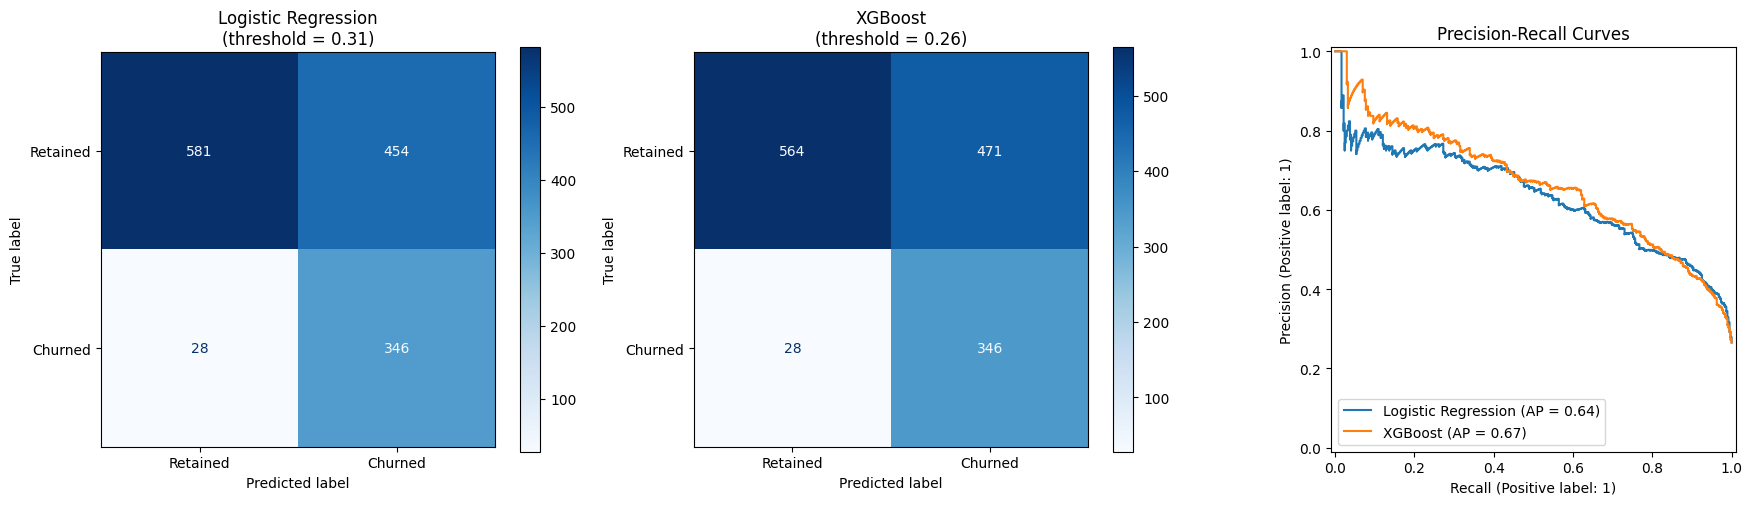

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(fitted_models):
    pred = (test_probas[name] >= thresholds[name]).astype(int)
    print(name, "\n", confusion_matrix(y_test, pred), "\n")
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Retained", "Churned"],
                                            cmap="Blues", ax=ax[i])
    ax[i].set_title(f"{name}\n(threshold = {thresholds[name]:.2f})")
for name in fitted_models:
    PrecisionRecallDisplay.from_predictions(y_test, test_probas[name], name=name, ax=ax[2])
ax[2].set_title("Precision-Recall Curves")
plt.tight_layout()
plt.show()

## [12] Output (test set only: customers the model has never seen)

In [14]:
test_proba = best_model.predict_proba(X_test)[:, 1]
scores = pd.DataFrame({
    "customerID": df.loc[X_test.index, "customerID"].values,
    "churn_risk_score": test_proba,
    "high_risk": (test_proba >= thresholds["XGBoost"]).astype(int),
    "actual_churn": y_test.values,
}).sort_values("churn_risk_score", ascending=False)

scores.to_csv("churn_scores.csv", index=False)
scores[scores["high_risk"] == 1].to_csv("high_risk_customers.csv", index=False)
joblib.dump({"model": best_model, "threshold": thresholds["XGBoost"]}, "churn_model.joblib")

print(f"High-risk customers: {scores['high_risk'].sum()} of {len(scores)} test customers")
scores.head(10)

High-risk customers: 817 of 1409 test customers


,customerID,churn_risk_score,high_risk,actual_churn
1090,5178-LMXOP,0.968104,1,1
1221,0295-PPHDO,0.962213,1,1
1109,1069-XAIEM,0.958844,1,1
647,6023-YEBUP,0.957239,1,1
618,9248-OJYKK,0.949677,1,1
1138,1400-MMYXY,0.949451,1,1
51,7181-BQYBV,0.943953,1,1
1164,8884-ADFVN,0.943903,1,1
344,6230-BSUXY,0.942715,1,1
1259,2609-IAICY,0.942599,1,1
